## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [2]:
import numpy as np
import pandas as pd

# utils
from utils.config import load_config
from utils.data import load_pkl
from utils.metrics import *
from utils.viz import *
from utils.style_transfer import style_transfer

# tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
import shap
from sklearn.linear_model import LogisticRegression

/export/usuarios01/agnavarr/MALDIAlign/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data loading

In [10]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]
marisma_pkl = cfg["data"]["MARISMa_REDUCED_PKL"]
msumg_pkl = cfg["data"]["MSUMG_PKL"]
rki_pkl = cfg["data"]["RKI_PKL"]

In [11]:
driams = load_pkl(driams_pkl)
marisma = load_pkl(marisma_pkl)
msumg = load_pkl(msumg_pkl)
rki = load_pkl(rki_pkl)

In [12]:
data_driams, label_driams, meta_driams = driams["data"], driams["label"], pd.DataFrame.from_records(list(driams["meta"]))
data_marisma, label_marisma, meta_marisma = marisma["data"], marisma["label"], pd.DataFrame.from_records(list(marisma["meta"]))
data_msumg, label_msumg, meta_msumg = msumg["data"], msumg["label"], pd.DataFrame.from_records(list(msumg["meta"]))
data_rki, label_rki, meta_rki = rki["data"], rki["label"], pd.DataFrame.from_records(list(rki["meta"]))

In [13]:
meta_marisma.insert(
    loc=0,
    column="hospital",
    value="MARISMA"
)

meta_msumg.insert(
    loc=0,
    column="hospital",
    value="MS-UMG"
)

meta_rki.insert(
    loc=0,
    column="hospital",
    value="RKI"
)

In [14]:
# Apply normalization: scale each spectrum to [0, 1]
X_min = data_driams.min(axis=1, keepdims=True)
X_max = data_driams.max(axis=1, keepdims=True)
data_norm = (data_driams - X_min) / (X_max - X_min + 1e-8)

# Apply normalization: scale each spectrum to [0, 1]
X_min_marisma = data_marisma.min(axis=1, keepdims=True)
X_max_marisma = data_marisma.max(axis=1, keepdims=True)
data_norm_marisma = (data_marisma - X_min_marisma) / (X_max_marisma - X_min_marisma + 1e-8)

# Apply normalization: scale each spectrum to [0, 1]
X_min = data_msumg.min(axis=1, keepdims=True)
X_max = data_msumg.max(axis=1, keepdims=True)
msumg_data = (data_msumg - X_min) / (X_max - X_min + 1e-8)

In [15]:
# Filter the data by hospital
filtered_data = {}
for hosp in meta_driams["hospital"].unique():
    idx = np.where(meta_driams["hospital"].values == hosp)[0]
    filtered_data[hosp] = {
        "data": data_norm[idx],
        "label": label_driams[idx],
        "meta": meta_driams.iloc[idx]
    }

In [16]:
# Declare the datasets
dataA, labelA, metaA = filtered_data["DRIAMS_A"]["data"], filtered_data["DRIAMS_A"]["label"], filtered_data["DRIAMS_A"]["meta"]
dataB, labelB, metaB = filtered_data["DRIAMS_B"]["data"], filtered_data["DRIAMS_B"]["label"], filtered_data["DRIAMS_B"]["meta"]
dataC, labelC, metaC = filtered_data["DRIAMS_C"]["data"], filtered_data["DRIAMS_C"]["label"], filtered_data["DRIAMS_C"]["meta"]
dataD, labelD, metaD = filtered_data["DRIAMS_D"]["data"], filtered_data["DRIAMS_D"]["label"], filtered_data["DRIAMS_D"]["meta"]

## Style transfer

#### Utils

In [17]:
import torch
from models.deep.MultiVAEPrior import MultiVAE_Bernoulli_SpeciesPrior_Extended

In [18]:
def load_model(model, path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

def encode_latent(model, X, device, batch_size=256):
    model.eval()
    Z = []

    X_tensor = torch.tensor(X, dtype=torch.float32)

    loader = torch.utils.data.DataLoader(
        X_tensor,
        batch_size=batch_size,
        shuffle=False
    )

    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            mu, _ = model.encoder(x)
            Z.append(mu.cpu().numpy())

    return np.vstack(Z)

#### Load MultiDecoder

In [20]:
meta_all = pd.concat([metaA, metaB, metaC, metaD, meta_marisma, meta_msumg], ignore_index=True)
data_all = np.vstack([dataA, dataB, dataC ,dataD, data_marisma, data_msumg])
label_all = np.concatenate([labelA, labelB, labelC, labelD, label_marisma, label_msumg])

In [23]:
vae_path = "/export/usuarios01/agnavarr/MALDIAlign/experiments/results/vae_multidecoder_prior_5domains/20260205_080627/model.pth"

backbone = MultiVAE_Bernoulli_SpeciesPrior_Extended(
    input_dim=data_all.shape[1],
    latent_dim=64,
    num_domains=5,
    n_species=len(np.unique(label_all))
)

vae = load_model(backbone, vae_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    dataA,
    labelA,
    test_size=0.2,
    stratify=labelA,
    shuffle=True,
    random_state=42
)

### Train

In [40]:
XA = encode_latent(vae, dataA, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))

In [41]:
XM = encode_latent(vae, data_msumg, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))

In [42]:
rf_driamsA = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)
rf_driamsA.fit(XA, labelA)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Test


===== Metrics =====
Domain: MS-UMG
Balanced Accuracy: 0.1633
F1 Macro: 0.0929
Recall Macro: 0.1633
Specificity Macro: 0.8328



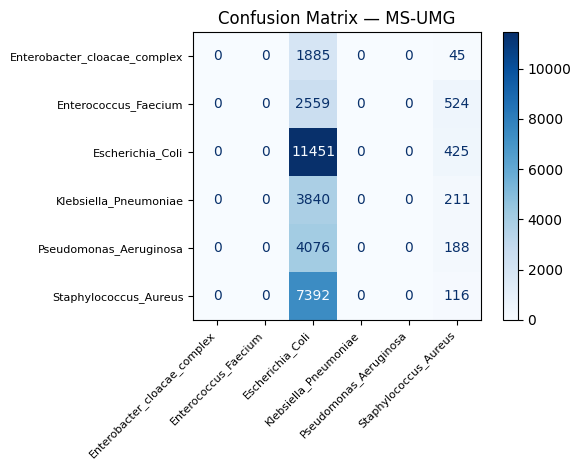

In [43]:
#metricsA = metrics_report(X_test, y_test, rf_driamsA, "DRIAMS-A")
metricsM = metrics_report(XM, label_msumg, rf_driamsA, "MS-UMG")

#print_metrics(metricsA)
print_metrics(metricsM)

### Transfer MS-UMG to A and check performance

In [34]:
DOMAIN_MAP = {
    "DRIAMS_A": 0,
    "DRIAMS_B": 1,
    "DRIAMS_C": 2,
    "DRIAMS_D": 3,
    "MARISMA": 4,
}


In [35]:
X_M_to_A = style_transfer(
    model=vae,
    X=data_msumg,
    domain_target_id=DOMAIN_MAP["DRIAMS_A"],
    device=device
)

In [37]:
X_min = X_M_to_A.min(axis=1, keepdims=True)
X_max = X_M_to_A.max(axis=1, keepdims=True)
X_M_to_A = (X_M_to_A - X_min) / (X_max - X_min + 1e-8)


===== Metrics =====
Domain: MS-UMG to A
Balanced Accuracy: 0.1667
F1 Macro: 0.0384
Recall Macro: 0.1667
Specificity Macro: 0.8333



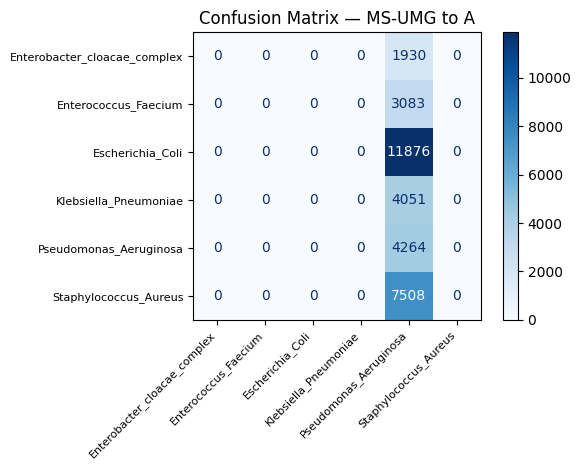

In [38]:
metricsM_to_A = metrics_report(X_M_to_A, label_msumg, rf_driamsA, "MS-UMG to A")
print_metrics(metricsM_to_A)